In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("../data/orders_clean.csv")
websession = pd.read_csv("../data/web_sessions_clean.csv")

orders["session_date"] = pd.to_datetime(orders["session_date"])
websession["session_date"] = pd.to_datetime(websession["session_date"])
orders.plot

# E-Commerce Product Analysis

## Project Overview

This project analyzes e-commerce sales and website session data to understand business performance, product performance,purchasing behavior, and conversion patterns.

The analysis uses **Python and pandas** to clean, transform, analyze, and visualize the data.

### Business Questions

- How is overall e-commerce performance?
- Which product categories generate the most revenue?
- How concentrated is revenue across products?
- Which acquisition channels generate the most revenue and conversions?
- How does conversion differ between desktop and mobile users?
- Where are the largest opportunities to improve conversion?
- How does revenue and conversion change over time?

### Tools Used

- Python
- Pandas
- Matplotlib
- PostgreSQL
- SQL
- Jupyter Notebook

### Dataset

The dataset contains:

- **25,000 website sessions**
- **3,037 purchasing sessions**
- **400 unique SKUs**
- Session, product, channel, device, cart, purchase, discount, revenue, and unit information

### Analysis Approach

The project follows an end-to-end analytical workflow:

**Data Quality → KPI Analysis → Product Analysis → Channel Analysis → Device Analysis → Conversion Funnel → Discount & Order Value Analysis → Time-Based Analysis → Business Insights**

## 1. Data Loading & Quality Checks

Before analyzing the data, I loaded the order and web session datasets and checked their structure, data types, missing values, and duplicate records.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("../data/orders_clean.csv")
websession = pd.read_csv("../data/web_sessions_clean.csv")

orders["session_date"] = pd.to_datetime(orders["session_date"])
websession["session_date"] = pd.to_datetime(websession["session_date"])

In [4]:
orders.head()

,session_id,session_date,device,channel,sku,category,discount_applied,order_value,units
0,16,2025-07-02,Desktop,Paid Social,SKU-0253,Apparel,0,38.82,3
1,20,2025-10-03,Mobile,Organic,SKU-0047,Apparel,1,47.27,3
2,23,2025-11-26,Mobile,Organic,SKU-0342,Apparel,1,65.95,3
3,41,2025-04-15,Desktop,Email,SKU-0333,Apparel,0,83.87,1
4,43,2025-08-27,Desktop,Organic,SKU-0136,Fitness,0,29.58,1


In [5]:
orders.shape

(3037, 9)

In [6]:
websession.head()

,session_id,session_date,device,channel,added_to_cart,purchased
0,1,2025-10-03,Desktop,Paid Social,1,0
1,2,2025-11-12,Mobile,Paid Search,0,0
2,3,2025-12-15,Desktop,Email,0,0
3,4,2025-03-18,Desktop,Organic,0,0
4,5,2025-09-02,Mobile,Paid Social,0,0


In [7]:
websession.shape

(25000, 6)

In [8]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 3037 entries, 0 to 3036
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   session_id        3037 non-null   int64         
 1   session_date      3037 non-null   datetime64[us]
 2   device            3037 non-null   str           
 3   channel           3037 non-null   str           
 4   sku               3037 non-null   str           
 5   category          3037 non-null   str           
 6   discount_applied  3037 non-null   int64         
 7   order_value       3037 non-null   float64       
 8   units             3037 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 213.7 KB


In [9]:
websession.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   session_id     25000 non-null  int64         
 1   session_date   25000 non-null  datetime64[us]
 2   device         25000 non-null  str           
 3   channel        25000 non-null  str           
 4   added_to_cart  25000 non-null  int64         
 5   purchased      25000 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 1.1 MB


In [10]:
orders.describe()

,session_id,session_date,discount_applied,order_value,units
count,3037.000000,3037,3037.000000,3037.000000,3037.000000
mean,12496.008561,2025-07-01 18:47:32.025024,0.365492,65.388864,2.002305
min,16.000000,2025-01-01 00:00:00,0.000000,9.200000,1.000000
25%,6317.000000,2025-04-01 00:00:00,0.000000,46.850000,1.000000
50%,12465.000000,2025-06-29 00:00:00,0.000000,65.750000,2.000000
75%,18727.000000,2025-10-03 00:00:00,1.000000,82.960000,3.000000
max,24998.000000,2025-12-31 00:00:00,1.000000,174.390000,3.000000
std,7214.867979,NaN,0.481647,26.208110,0.817904


In [11]:
websession.describe()

,session_id,session_date,added_to_cart,purchased
count,25000.000000,25000,25000.00000,25000.000000
mean,12500.500000,2025-07-02 19:30:05.184000,0.33968,0.121480
min,1.000000,2025-01-01 00:00:00,0.00000,0.000000
25%,6250.750000,2025-04-02 00:00:00,0.00000,0.000000
50%,12500.500000,2025-07-04 00:00:00,0.00000,0.000000
75%,18750.250000,2025-10-03 00:00:00,1.00000,0.000000
max,25000.000000,2025-12-31 00:00:00,1.00000,1.000000
std,7217.022701,NaN,0.47361,0.326691


In [12]:
orders.isnull().sum()

session_id          0
session_date        0
device              0
channel             0
sku                 0
category            0
discount_applied    0
order_value         0
units               0
dtype: int64

In [13]:
websession.isnull().sum()

session_id       0
session_date     0
device           0
channel          0
added_to_cart    0
purchased        0
dtype: int64

In [14]:
orders.duplicated().sum()

np.int64(0)

In [15]:
websession.duplicated().sum()

np.int64(0)

## 2. Overall Business Performance

I calculated key performance indicators (KPIs) to establish a baseline for the e-commerce business, including total sessions, purchases, conversion rate, revenue, units sold, and average order value.

In [16]:
total_sessions = len(websession)
total_purchases = websession["purchased"].sum()
total_revenue = orders["order_value"].sum()
total_units = orders["units"].sum()

add_to_cart_rate = (
    websession["added_to_cart"].sum()
    / total_sessions * 100
)

conversion_rate = (
    total_purchases
    / total_sessions * 100
)

abandoned_carts = (
    websession["added_to_cart"].sum()
    - total_purchases
)

cart_abandonment_rate = (
    abandoned_carts
    / websession["added_to_cart"].sum() * 100
)

average_order_value = (
    total_revenue / total_purchases
)

kpi_table = pd.DataFrame({
    "KPI": [
        "Total Sessions",
        "Purchases",
        "Add-to-Cart Rate",
        "Conversion Rate",
        "Cart Abandonment Rate",
        "Total Units",
        "Total Revenue",
        "Average Order Value"
    ],
    "Value": [
        total_sessions,
        total_purchases,
        f"{add_to_cart_rate:.2f}%",
        f"{conversion_rate:.2f}%",
        f"{cart_abandonment_rate:.2f}%",
        total_units,
        f"${total_revenue:,.2f}",
        f"${average_order_value:.2f}"
    ]
})

kpi_table

,KPI,Value
0,Total Sessions,25000
1,Purchases,3037
2,Add-to-Cart Rate,33.97%
3,Conversion Rate,12.15%
4,Cart Abandonment Rate,64.24%
5,Total Units,6081
6,Total Revenue,"$198,585.98"
7,Average Order Value,$65.39


## 3. Product Performance Analysis

I analyzed product categories and individual SKUs to identify revenue patterns, product concentration, and areas of strong or weak performance.

In [17]:
category_analysis = (
    orders.groupby("category")
    .agg(
        total_units=("units", "sum"),
        total_revenue=("order_value", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

category_analysis.round(2)

,total_units,total_revenue
category,,
Apparel,1778,57494.97
Home,1293,42036.37
Electronics,1182,39750.30
Beauty,1129,35315.78
Fitness,699,23988.56


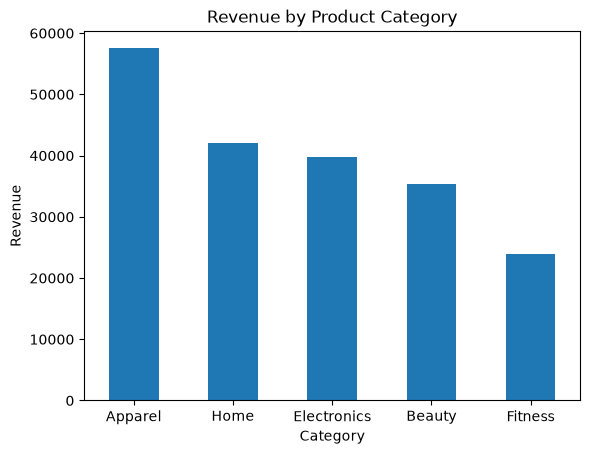

In [70]:
category_analysis["total_revenue"].plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

In [122]:
print (type (category_analysis["total_revenue"]))

<class 'pandas.Series'>


In [123]:
top_skus = (
    orders.groupby(["sku", "category"])
    .agg(
        total_units=("units", "sum"),
        total_revenue=("order_value", "sum")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

top_skus.round(2)

,,total_units,total_revenue
sku,category,,
SKU-0122,Apparel,14,524.79
SKU-0143,Apparel,9,520.40
SKU-0213,Apparel,15,480.31
SKU-0395,Apparel,17,451.67
SKU-0072,Fitness,10,421.03
SKU-0344,Apparel,12,419.06
SKU-0063,Home,11,417.16
SKU-0246,Apparel,13,416.71
SKU-0224,Electronics,10,410.08


###  Revenue Concentration

I analyzed cumulative SKU revenue to understand whether the business depends heavily on a small number of products.

In [124]:
sku_revenue = (
    orders.groupby("sku")
    .agg(
        total_revenue=("order_value", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

sku_revenue["cumulative_revenue"] = (
    sku_revenue["total_revenue"].cumsum()
)

sku_revenue["cumulative_revenue_pct"] = (
    sku_revenue["cumulative_revenue"]
    / sku_revenue["total_revenue"].sum()
    * 100
)

sku_revenue.head(20).round(2)

,total_revenue,cumulative_revenue,cumulative_revenue_pct
sku,,,
SKU-0028,1249.99,1249.99,0.63
SKU-0143,992.65,2242.64,1.13
SKU-0081,948.51,3191.15,1.61
SKU-0339,930.70,4121.85,2.08
SKU-0104,920.64,5042.49,2.54
SKU-0344,903.81,5946.30,2.99
SKU-0122,896.86,6843.16,3.45
SKU-0273,889.10,7732.26,3.89
SKU-0234,879.20,8611.46,4.34


In [125]:
top_10_pct = int(len(sku_revenue) * 0.10)

top_10_revenue_share = (
    sku_revenue.head(top_10_pct)["total_revenue"].sum()
    / sku_revenue["total_revenue"].sum()
    * 100
)

print("Total SKUs:", len(sku_revenue))
print("Top 10% of SKUs:", top_10_pct)
print("Revenue share of top 10%:", round(top_10_revenue_share, 2), "%")

Total SKUs: 400
Top 10% of SKUs: 40
Revenue share of top 10%: 17.08 %


In [126]:
sku_50_pct = (
    sku_revenue["cumulative_revenue_pct"] <= 50
).sum()

print("SKUs generating up to 50% of revenue:", sku_50_pct)
print(
    "Share of total SKUs:",
    round(sku_50_pct / len(sku_revenue) * 100, 2),
    "%"
)

SKUs generating up to 50% of revenue: 139
Share of total SKUs: 34.75 %


## 4. Channel Performance Analysis

I analyzed acquisition channels to compare revenue contribution, purchasing volume, and conversion performance.

In [127]:
channel_analysis = (
    orders.groupby("channel")
    .agg(
        orders=("session_id", "nunique"),
        total_units=("units", "sum"),
        total_revenue=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

channel_analysis.round(2)


,orders,total_units,total_revenue,average_order_value
channel,,,,
Paid Search,899,1802,58320.29,64.87
Organic,838,1702,54278.58,64.77
Paid Social,556,1086,36509.16,65.66
Email,438,866,29417.64,67.16
Affiliate,306,625,20060.31,65.56


In [128]:
channel_conversion = (
    websession.groupby("channel")
    .agg(
        total_sessions=("session_id", "count"),
        cart_sessions=("added_to_cart", "sum"),
        purchases=("purchased", "sum")
    )
)

channel_conversion["add_to_cart_rate"] = (
    channel_conversion["cart_sessions"]
    / channel_conversion["total_sessions"] * 100
)

channel_conversion["conversion_rate"] = (
    channel_conversion["purchases"]
    / channel_conversion["total_sessions"] * 100
)

channel_conversion = channel_conversion.sort_values(
    "conversion_rate",
    ascending=False
)

channel_conversion.round(2)

,total_sessions,cart_sessions,purchases,add_to_cart_rate,conversion_rate
channel,,,,,
Paid Search,7117,2428,899,34.12,12.63
Affiliate,2433,882,306,36.25,12.58
Email,3556,1189,438,33.44,12.32
Paid Social,4654,1543,556,33.15,11.95
Organic,7240,2450,838,33.84,11.57


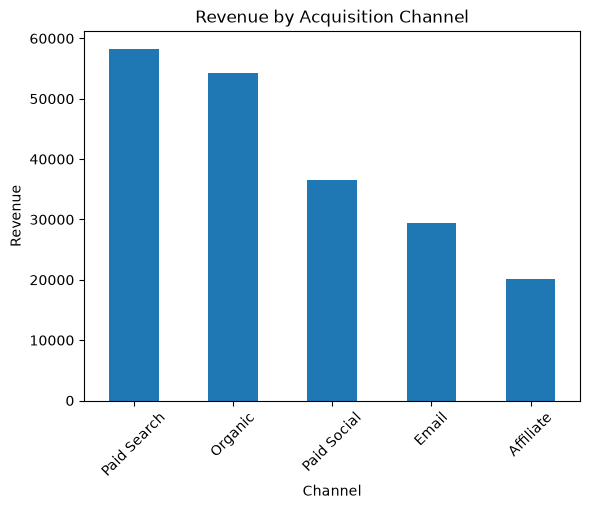

In [129]:
channel_analysis["total_revenue"].plot(kind="bar")

plt.title("Revenue by Acquisition Channel")
plt.xlabel("Channel")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

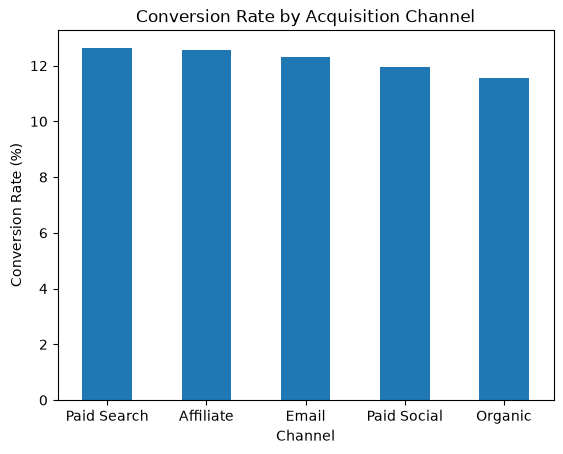

In [147]:
channel_conversion["conversion_rate"].plot(kind="bar")

plt.title("Conversion Rate by Acquisition Channel")
plt.xlabel("Channel")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()

## 5. Device Performance Analysis

I compared website performance across devices to identify differences in user engagement and conversion between desktop and mobile sessions.

In [148]:
device_analysis = (
    websession.groupby("device")
    .agg(
        total_sessions=("session_id", "count"),
        cart_sessions=("added_to_cart", "sum"),
        purchases=("purchased", "sum")
    )
)

device_analysis["add_to_cart_rate"] = (
    device_analysis["cart_sessions"]
    / device_analysis["total_sessions"] * 100
)

device_analysis["conversion_rate"] = (
    device_analysis["purchases"]
    / device_analysis["total_sessions"] * 100
)

device_analysis.round(2)

,total_sessions,cart_sessions,purchases,add_to_cart_rate,conversion_rate
device,,,,,
Desktop,12087,4356,1620,36.04,13.40
Mobile,12913,4136,1417,32.03,10.97


In [149]:
device_channel = (
    websession.groupby(["device", "channel"])
    .agg(
        total_sessions=("session_id", "count"),
        purchases=("purchased", "sum")
    )
)

device_channel["conversion_rate"] = (
    device_channel["purchases"]
    / device_channel["total_sessions"] * 100
)

device_channel.round(2)

total_sessions  purchases  conversion_rate
device  channel                                                
Desktop Affiliate              1201        153            12.74
        Email                  1739        239            13.74
        Organic                3452        431            12.49
        Paid Search            3448        475            13.78
        Paid Social            2247        322            14.33
Mobile  Affiliate              1232        153            12.42
        Email                  1817        199            10.95
        Organic                3788        407            10.74
        Paid Search            3669        424            11.56
        Paid Social            2407        234             9.72

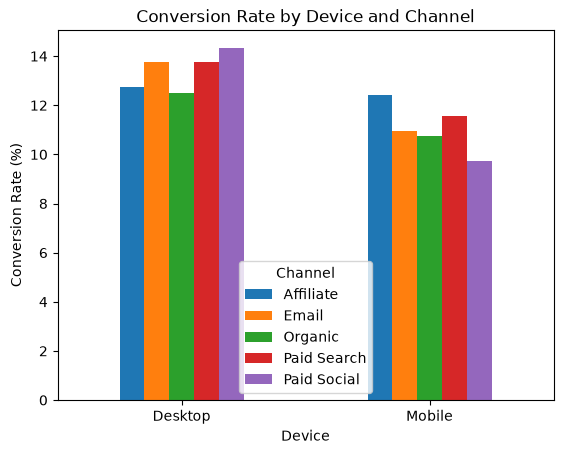

In [150]:
device_channel["conversion_rate"].unstack().plot(kind="bar")

plt.title("Conversion Rate by Device and Channel")
plt.xlabel("Device")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Channel")
plt.show()

## 6. Conversion Funnel Analysis

I analyzed the user journey from website session to cart addition and purchase to identify where potential users are lost during the purchasing process.

In [151]:
funnel = {
    "Total Sessions": len(websession),
    "Cart Sessions": websession["added_to_cart"].sum(),
    "Purchase Sessions": websession["purchased"].sum()
}

funnel_table = pd.DataFrame({
    "Stage": funnel.keys(),
    "Count": funnel.values()
})

funnel_table

,Stage,Count
0,Total Sessions,25000
1,Cart Sessions,8492
2,Purchase Sessions,3037


In [152]:
funnel_rates = {
    "Session → Cart (%)": (
        websession["added_to_cart"].sum()
        / len(websession) * 100
    ),
    "Cart → Purchase (%)": (
        websession["purchased"].sum()
        / websession["added_to_cart"].sum() * 100
    ),
    "Session → Purchase (%)": (
        websession["purchased"].sum()
        / len(websession) * 100
    )
}

funnel_rates

{'Session → Cart (%)': np.float64(33.967999999999996),
 'Cart → Purchase (%)': np.float64(35.76307112576543),
 'Session → Purchase (%)': np.float64(12.148)}

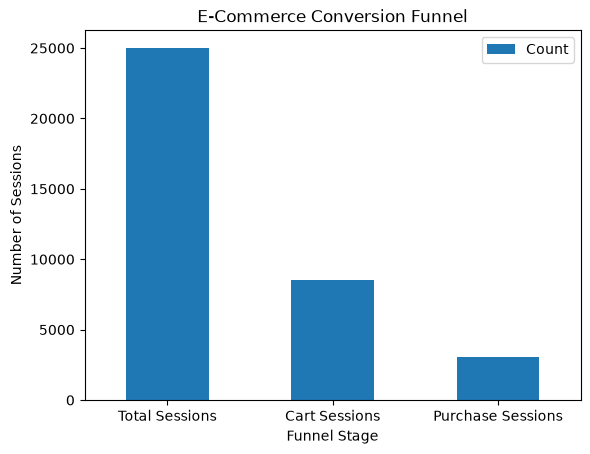

In [153]:
funnel_table.plot(
    x="Stage",
    y="Count",
    kind="bar"
)

plt.title("E-Commerce Conversion Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.show()

## 7. Discount & Order Value Analysis

I analyzed purchasing behavior by discount usage and order value to understand how discounts relate to revenue and the distribution of purchase sizes.

In [154]:
discount_analysis = (
    orders.groupby("discount_applied")
    .agg(
        purchasing_sessions=("session_id", "nunique"),
        total_units=("units", "sum"),
        total_revenue=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
)

discount_analysis.round(2)

,purchasing_sessions,total_units,total_revenue,average_order_value
discount_applied,,,,
0,1927,3848,129961.02,67.44
1,1110,2233,68624.96,61.82


In [155]:
orders["order_value_segment"] = pd.cut(
    orders["order_value"],
    bins=[0, 50, 100, 150, float("inf")],
    labels=["Under $50", "$50–$99", "$100–$149", "$150+"],
    right=False
)

order_value_analysis = (
    orders.groupby("order_value_segment", observed=False)
    .agg(
        purchasing_sessions=("session_id", "nunique"),
        total_units=("units", "sum"),
        total_revenue=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
)

order_value_analysis.round(2)

,purchasing_sessions,total_units,total_revenue,average_order_value
order_value_segment,,,,
Under $50,867,1769,29515.54,34.04
$50–$99,1884,3730,136793.95,72.61
$100–$149,283,577,31789.17,112.33
$150+,3,5,487.32,162.44


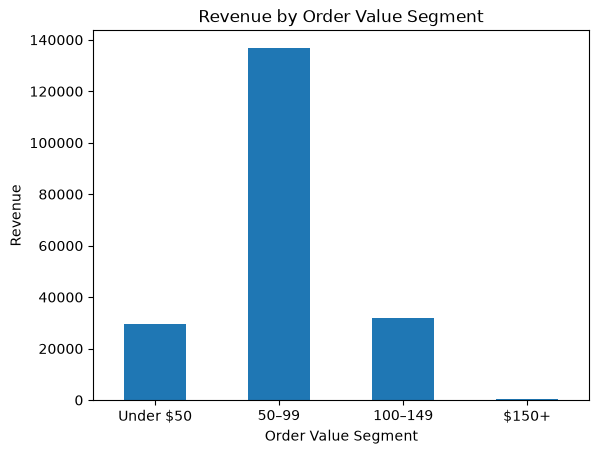

In [156]:
order_value_analysis["total_revenue"].plot(kind="bar")

plt.title("Revenue by Order Value Segment")
plt.xlabel("Order Value Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

In [157]:
order_value_analysis = (
    orders.groupby("order_value_segment", observed=False)
    .agg(
        purchasing_sessions=("session_id", "nunique"),
        total_units=("units", "sum"),
        total_revenue=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
)

In [158]:
order_value_analysis.round(2)

,purchasing_sessions,total_units,total_revenue,average_order_value
order_value_segment,,,,
Under $50,867,1769,29515.54,34.04
$50–$99,1884,3730,136793.95,72.61
$100–$149,283,577,31789.17,112.33
$150+,3,5,487.32,162.44


## 8. Monthly Performance Analysis

I analyzed monthly sales and conversion performance to identify changes in revenue, purchasing volume, and website conversion throughout the year.

In [159]:
monthly_sales = (
    orders.groupby(orders["session_date"].dt.to_period("M"))
    .agg(
        purchasing_sessions=("session_id", "nunique"),
        total_units=("units", "sum"),
        total_revenue=("order_value", "sum")
    )
)

monthly_sales.round(2)

,purchasing_sessions,total_units,total_revenue
session_date,,,
2025-01,271,544,18217.34
2025-02,234,476,15563.04
2025-03,248,479,16022.85
2025-04,256,490,17297.31
2025-05,259,522,16549.44
2025-06,261,527,17571.03
2025-07,242,478,15760.53
2025-08,258,520,16302.75
2025-09,229,462,15271.67


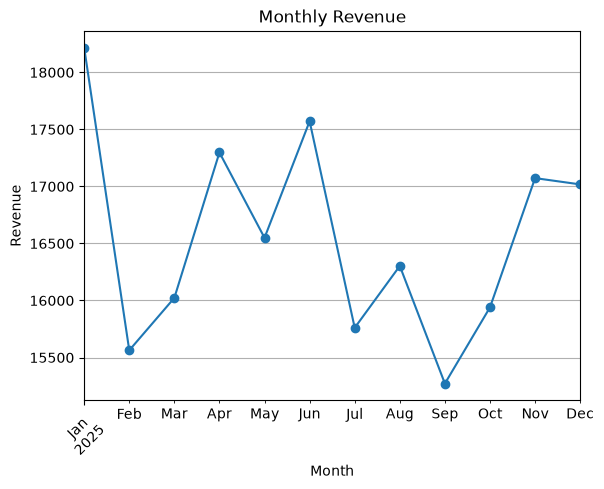

In [160]:
monthly_sales["total_revenue"].plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [161]:
monthly_conversion = (
    websession.groupby(websession["session_date"].dt.to_period("M"))
    .agg(
        total_sessions=("session_id", "count"),
        purchases=("purchased", "sum")
    )
)

monthly_conversion["conversion_rate"] = (
    monthly_conversion["purchases"]
    / monthly_conversion["total_sessions"] * 100
)

monthly_conversion.round(2)

,total_sessions,purchases,conversion_rate
session_date,,,
2025-01,2149,271,12.61
2025-02,1926,234,12.15
2025-03,2070,248,11.98
2025-04,2022,256,12.66
2025-05,2048,259,12.65
2025-06,2054,261,12.71
2025-07,2099,242,11.53
2025-08,2154,258,11.98
2025-09,2082,229,11.00


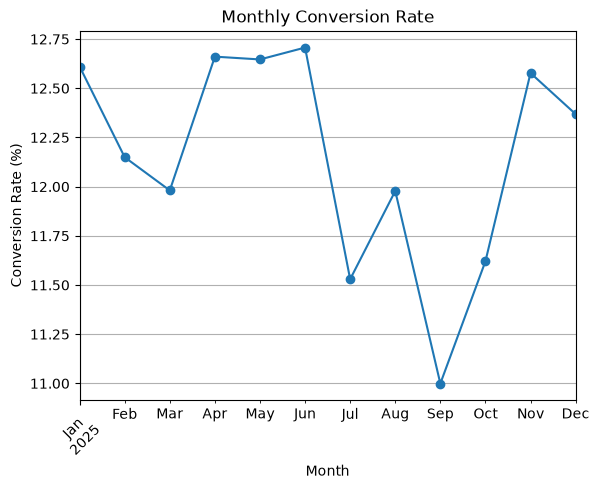

In [162]:
monthly_conversion["conversion_rate"].plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 9. Key Business Findings

The analysis identified several important patterns across conversion, products, channels, devices, and revenue.

In [163]:
key_findings = pd.DataFrame({
    "Finding": [
        "Overall Conversion Rate",
        "Cart Abandonment Rate",
        "Desktop Conversion Rate",
        "Mobile Conversion Rate",
        "Top 10% SKU Revenue Share",
        "SKUs Needed for 50% of Revenue"
    ],
    "Value": [
        f"{conversion_rate:.2f}%",
        f"{cart_abandonment_rate:.2f}%",
        f"{device_analysis.loc['Desktop', 'conversion_rate']:.2f}%",
        f"{device_analysis.loc['Mobile', 'conversion_rate']:.2f}%",
        f"{top_10_revenue_share:.2f}%",
        "140 SKUs (35% of catalog)"
    ]
})

key_findings

,Finding,Value
0,Overall Conversion Rate,12.15%
1,Cart Abandonment Rate,64.24%
2,Desktop Conversion Rate,13.40%
3,Mobile Conversion Rate,10.97%
4,Top 10% SKU Revenue Share,17.08%
5,SKUs Needed for 50% of Revenue,140 SKUs (35% of catalog)


## Business Insights

### 1. High Cart Abandonment

The e-commerce website recorded 25,000 sessions and 8,492 cart sessions. Of these, 5,455 carts were abandoned, resulting in a 64.24% cart abandonment rate.

**Business implication:** The checkout and purchasing journey should be investigated to identify potential barriers preventing customers from completing purchases.

### 2. Mobile Conversion Is Lower Than Desktop

Desktop users had a conversion rate of 13.40%, compared with 10.97% for mobile users, a difference of 2.43 percentage points.

**Business implication:** The mobile shopping experience should be investigated, particularly the checkout process, usability, and performance.

### 3. Revenue Is Broadly Distributed Across SKUs

The analysis covers 400 SKUs. The top 10% of SKUs generate 17.08% of total revenue, while approximately 35% of the catalog is needed to reach 50% of total revenue.

**Business implication:** Revenue is distributed across a relatively broad product catalog rather than being concentrated in a small number of products.

### 4. Paid Search Generates the Highest Revenue

Paid Search generated $58,320.29 in revenue from 899 purchasing sessions. Organic traffic generated the largest number of sessions but had the lowest conversion rate among the channels analyzed, at 11.57%.

**Business implication:** Channel performance should be evaluated using both traffic volume and conversion rather than traffic alone.

### 5. The $50–$99 Order Segment Drives Most Revenue

The $50–$99 order-value segment generated $136,793.95 in revenue from 1,884 purchasing sessions, making it the largest order-value segment by both purchase volume and revenue.

**Business implication:** Products and promotions within this price range may warrant closer analysis when evaluating revenue growth opportunities.

### Analytical Note

These findings describe patterns in the dataset and do not establish causal relationships. Further analysis or experimentation would be required to determine whether specific changes would improve conversion or revenue.